# FORMATIVE ASSESSMENT OF ADOLESCENT GIRLS AND YOUNG WOMEN’S HIV, GENDER-BASED VIOLENCE AND SEXUAL AND REPRODUCTIVE HEALTH STATUS

## Background
Teenage pregnancy and motherhood have been a major health and social concern in Uganda as it infringes upon the human rights of girls but also hinders their ability to achieve their full socioeconomic development. Teenagers who engage in sexual intercourse at a young age face an elevated risk of becoming pregnant and giving birth. The 2022 UDHS indicated that 23.5% of women age 15-19 had initiated childbearing by the time of the survey, with 18.4% having already had a live birth, while 5.1% were pregnant with their first child.

Patterns by background characteristics:
* By age 16, 1 in every 10 women age 15-19 has begun childbearing. This percentage significantly rises to almost 4 out of every 10 by the time they reach 18 (Table 5.12).
* Teenagers in rural areas started childbearing earlier than those in urban areas. Twenty five percent of women age 15-19 in rural areas have begun childbearing, compared with 21% in urban areas.
* Teenage childbearing varies by region. The percentage of women age 15-19 who have begun childbearing ranges from 15% in Kigezi region to 28 % -30% in Busoga and Bukedi sub regions.
* The proportion of women age 15-19 who have begun childbearing decreases with both education and wealth.

The selection of the districts that we surveyed was informed by HIV prevalence dynamics and implementing partner support: we went to districts where there were Global Fund-supported implementing partners working to reduce the new number of new HIV infections among AGYW, improve SRH (e.g. reduce teenage pregnancy) and GBV indicators in the targeted districts.

## Data Processing

The output of this notebook includes four cleaned data frames, ready for further analysis.

## Load dataset

In [14]:
# File paths [update with your file path]
data_path = (
    '/Users/nataschajademinnitt/Documents/5. Data Analysis/unicef_teenage_preg/data/'
)

figures_path_drivers = (
    '/Users/nataschajademinnitt/Documents/5. Data Analysis/unicef_teenage_preg/results/figures/drivers/')

figures_path_effects = (
    '/Users/nataschajademinnitt/Documents/5. Data Analysis/unicef_teenage_preg/results/figures/effects/'
)

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# Set environment
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", context="paper")

# Load the Stata file (.dta)
df_clean = pd.read_csv(data_path + "processed_df.csv")

In [18]:
# Ensure wealth_tertile is ordered correctly
df_clean['wealth_tertile'] = pd.Categorical(
    df_clean['wealth_tertile'],
    categories=['Low', 'Medium', 'High'],
    ordered=True
)

In [20]:
# median age of girls who fall pregnant for each wealth tertile
median_age_by_wealth = df_clean[df_clean['been_preg'] == 1].groupby('wealth_tertile', observed=False)['age_preg'].median()
print(median_age_by_wealth)

wealth_tertile
Low      17.00
Medium   17.00
High     18.00
Name: age_preg, dtype: float64


## Drivers of Teenage Pregnancy

In [8]:
# Girls age 10 - 19 cohort 1 (time-sensitive) -> girls who fell pregnant within 2 years of 10 - 19 (proximiate)
df_sensitive = df_clean[(df_clean['cohort_1'] == '10-14') | (df_clean['cohort_1'] == '15-19')].copy()

# Girls age 10 - 19 cohort 2 (time-insensitive) -> girls who fell pregnant within 2 years of 10 - 19 (distant)
df_insensitive = df_clean[(df_clean['cohort_2'] == '10-14') | (df_clean['cohort_2'] == '15-19')].copy()

### Household wealth and pregnancy outcomes

Indicators of household wealth are time sensitive, therefore the dataframe: df_sensitive is used (girls are within 3 years of their first pregnancy).

#### Overall

In [15]:
# Create contingency table for been_preg by wealth_tertile
contingency_table = pd.crosstab(df_sensitive['been_preg'], df_sensitive['wealth_tertile'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test statistic: {chi2:.2f}, p-value: {p:.4f}")

# Fit a logistic regression model with wealth_tertile as a categorical predictor
logit_model = smf.logit("been_preg ~ C(wealth_tertile)", data=df_sensitive).fit()
print(logit_model.summary())

Chi-square test statistic: 172.40, p-value: 0.0000
Optimization terminated successfully.
         Current function value: 0.450496
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              been_preg   No. Observations:                 5183
Model:                          Logit   Df Residuals:                     5180
Method:                           MLE   Df Model:                            2
Date:                Wed, 26 Feb 2025   Pseudo R-squ.:                 0.03837
Time:                        19:48:37   Log-Likelihood:                -2334.9
converged:                       True   LL-Null:                       -2428.1
Covariance Type:            nonrobust   LLR p-value:                 3.427e-41
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept              

### Marital status and pregnancy outcomes

Indicators of been married are not time sensitive, therefore the dataframe: df_insensitive is used.

#### Overall

In [21]:
import numpy as np

# Copy the original dataframe (adjust the name if needed)
df_analysis = df_insensitive.copy()

# Filter for girls who have been married and have been pregnant
df_analysis = df_analysis[(df_analysis['been_married_binary'] == 1) & (df_analysis['been_preg'] == 1)]

# Create a new column 'timing':
# 'preg_before' if age at pregnancy is less than age at marriage, otherwise 'preg_after'
df_analysis['timing'] = np.where(df_analysis['age_preg'] < df_analysis['age_marry'], 
                                 'preg_before', 
                                 'preg_after')

# Display the counts for each timing category
print(df_analysis['timing'].value_counts())

timing
preg_after     1012
preg_before     227
Name: count, dtype: int64


In [22]:
print(df_analysis['timing'].value_counts(normalize=True))

timing
preg_after    0.82
preg_before   0.18
Name: proportion, dtype: float64


In [23]:
# For girls who are married and pregnant, keep only those where marriage occurred before pregnancy
df_analysis = df_insensitive.copy()
df_analysis = df_analysis[~((df_analysis['been_married_binary'] == 1) &
                            (df_analysis['been_preg'] == 1) &
                            (df_analysis['age_preg'] < df_analysis['age_marry']))]

print(df_analysis.groupby(['been_married_binary', 'been_preg']).size().reset_index(name='count'))
print(df_insensitive.groupby(['been_married_binary', 'been_preg']).size().reset_index(name='count'))

   been_married_binary  been_preg  count
0                    0          0   4156
1                    0          1    686
2                    1          0    104
3                    1          1   1012
   been_married_binary  been_preg  count
0                    0          0   4156
1                    0          1    686
2                    1          0    104
3                    1          1   1239


In [24]:
# Create a contingency table of marriage (1/0) versus pregnancy (1/0)
contingency_table = pd.crosstab(df_analysis['been_married_binary'], df_analysis['been_preg'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test statistic: {chi2:.2f}, p-value: {p:.4f}")

# Fit logistic regression model with pregnancy as the outcome and marriage as the predictor
logit_model = smf.logit("been_preg ~ been_married_binary", data=df_analysis).fit()
print(logit_model.summary())

Chi-square test statistic: 2601.90, p-value: 0.0000
Optimization terminated successfully.
         Current function value: 0.389613
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              been_preg   No. Observations:                 5958
Model:                          Logit   Df Residuals:                     5956
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Feb 2025   Pseudo R-squ.:                  0.3480
Time:                        19:48:37   Log-Likelihood:                -2321.3
converged:                       True   LL-Null:                       -3560.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.8014      0.

### School status and pregnancy outcomes

Indicators of ever attending school are time insensitive, therefore the dataframe: df_insensitive is used.

#### Overall

In [30]:
# Create the contingency table
contingency_table = pd.crosstab(df_insensitive['attend_scol'], df_insensitive['been_preg'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test statistic: {chi2:.2f}, p-value: {p:.4f}")

# Fit logistic regression model with pregnancy as the outcome and school attendance as the predictor
logit_model = smf.logit("been_preg ~ attend_scol", data=df_insensitive).fit()
print(logit_model.summary())

Chi-square test statistic: 82.63, p-value: 0.0000
Optimization terminated successfully.
         Current function value: 0.613915
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              been_preg   No. Observations:                 6185
Model:                          Logit   Df Residuals:                     6183
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Feb 2025   Pseudo R-squ.:                0.009953
Time:                        19:48:38   Log-Likelihood:                -3797.1
converged:                       True   LL-Null:                       -3835.2
Covariance Type:            nonrobust   LLR p-value:                 2.382e-18
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8199      0.197  

The chi-square test shows a highly significant association between school attendance and pregnancy (χ² = 82.63, p < 0.0001), meaning that pregnancy rates differ by whether a girl attends school. The logistic regression further quantifies this relationship. With non-attenders as the reference, the intercept of 0.82 indicates the baseline log odds of pregnancy for girls not attending school. The coefficient for attending school is –1.65, which translates to an odds ratio of about exp(–1.65) ≈ 0.19. In plain language, girls who attend school have roughly an 81% lower chance of being pregnant compared to those who do not attend school.

### Time since sexual debut

By calculating the time interval between sexual debut (age_sex) and first pregnancy (age_preg), you can assess how quickly girls become pregnant after becoming sexually active. This analysis can shed light on early pregnancy risks and help identify critical periods for reproductive health interventions, such as increasing access to contraception and sexual education.

Among girls who have never been pregnant, how many have had sex?

This can provide insights into:
* Risk exposure: How many non-pregnant girls are sexually active and thus at potential risk for pregnancy?
* Protective factors: Are there differences between in-school vs. out-of-school girls in terms of sexual activity?

In [35]:
# Filter dataset for girls who have NOT been pregnant
df_non_preg = df_insensitive[df_insensitive['been_preg'] == 0].copy()

# Calculate proportion who have had sex
sexually_active_rate = df_non_preg['life_sex'].value_counts()

# Display results
sexually_active_rate

life_sex
0    3036
1    1224
Name: count, dtype: int64

In [56]:
df_non_preg.do_anything.value_counts(normalize=True)

do_anything
1.00   0.62
2.00   0.38
3.00   0.01
Name: proportion, dtype: float64

In [60]:
df = df_insensitive.copy()
df = df[df['life_sex'] == 1]

# Group by 'been_preg' and 'do_anything' and count occurrences
grouped = df.groupby(['been_preg', 'do_anything']).size().reset_index(name='count')

# Compute the total counts for each 'been_preg' group
total_counts = df.groupby('been_preg').size().reset_index(name='total')

# Merge the grouped counts with the totals
merged = pd.merge(grouped, total_counts, on='been_preg')

# Calculate the percentage within each 'been_preg' group
merged['percent'] = merged['count'] / merged['total'] * 100

print(merged)

   been_preg  do_anything  count  total  percent
0          0         1.00    721   1224    58.91
1          0         2.00    437   1224    35.70
2          0         3.00      8   1224     0.65
3          1         1.00    662   1925    34.39
4          1         2.00   1145   1925    59.48
5          1         3.00     27   1925     1.40


In [70]:
df = df_insensitive.copy()
df = df[df['life_sex'] == 1]
df.been_preg.value_counts()

been_preg
1    1925
0    1224
Name: count, dtype: int64

In [72]:
df = df_insensitive.copy()
df = df[df['life_sex'] == 1]
df.do_anything.value_counts()

do_anything
2.00    1582
1.00    1383
3.00      35
Name: count, dtype: int64

Probability of getting pregnant within 1 year(s): 73.30%


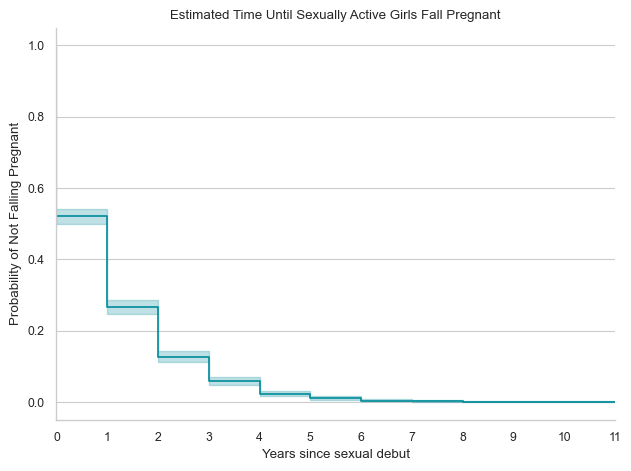

In [96]:
from lifelines import KaplanMeierFitter

# Work with a copy of your data and filter to include only sexually active girls
df = df_insensitive.copy()
df = df[df['life_sex'] == 1]
df = df[df['sex_age'].notna()]

# Create an event indicator:
# 1 if the girl got pregnant (i.e., age_preg is not missing), 0 if she did not (censored)
df['event'] = df['age_preg'].notna().astype(int)

# Compute the time-to-event (in years) as the difference between the age of pregnancy and sexual debut.
# For girls who haven't become pregnant, use their current age (assumed to be in a column 'current_age')
df['duration'] = df.apply(
    lambda row: row['age_preg'] - row['sex_age'] if row['event'] == 1 
                else row['age_completed'] - row['sex_age'],
    axis=1
)

# Define the threshold for "quick" pregnancy (e.g., within 1 year of sexual debut)
threshold = 1

# Fit the Kaplan-Meier estimator using the durations and the event indicator
kmf = KaplanMeierFitter()
kmf.fit(durations=df['duration'], event_observed=df['event'])

# The Kaplan-Meier survival function estimates the probability of NOT having become pregnant.
# To get the probability of pregnancy by the threshold, we take 1 minus the survival probability at that time.
survival_prob_at_threshold = kmf.predict(threshold)
prob_pregnant_within_threshold = 1 - survival_prob_at_threshold

print(f"Probability of getting pregnant within {threshold} year(s): {prob_pregnant_within_threshold:.2%}")

# Optional: plot the survival function and mark the threshold
ax = kmf.plot_survival_function(color="#008b9a")
plt.xticks(np.arange(0, 12, 1))
plt.xlim(0, 11)
plt.title("Estimated Time Until Sexually Active Girls Fall Pregnant")
plt.xlabel("Years since sexual debut")
plt.ylabel("Probability of Not Falling Pregnant")
plt.legend()
sns.despine(right=True, top=True)
plt.grid(False, axis='x')
ax.get_legend().remove()

# Save
plt.tight_layout()
plt.savefig(figures_path_drivers + 'km_estimate_time_to_preg.png')
plt.show()

## Effects of Teenage Pregnancy

In [37]:
# Looking at girls who experience pregnancy
df_effects = df_clean[df_clean['been_preg'] == 1]

# Girls age 10 - 19 cohort 1 (time-sensitive) -> girls who fell pregnant within 2 years of 10 - 19 (proximiate)
df_sensitive = df_effects[(df_effects['cohort_1'] == '10-14') | (df_effects['cohort_1'] == '15-19')].copy()

# Girls age 10 - 19 cohort 2 (time-insensitive) -> girls who fell pregnant within 2 years of 10 - 19 (distant)
df_insensitive = df_effects[(df_effects['cohort_2'] == '10-14') | (df_effects['cohort_2'] == '15-19')].copy()

### Effects on Education

#### Overall

The main reason for dropping out is due to a Lack of fees, 69.5% (1166).
The second reason for dropping out is Got pregnant, 27.9% (468).


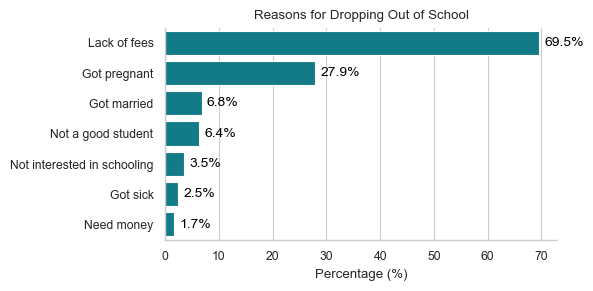

In [103]:
# What are some of the main reasons you are not in school?
count = df_insensitive.loc[(df_insensitive['attend_scol'] == 'Yes') & (df_insensitive['scol_status'] == 'Out of school')]

# Define dropout reasons
dropout_reasons = ['lack_fees', 'got_preg', 'got_married', 'got_sick', 'need_money', 'good_std', 'int_scol']

# Calculate count for each dropout reason
count_reasons_drop_out = count[dropout_reasons].apply(lambda col: (col == 1).sum()).to_frame(name='Count')
total_individuals = (count[dropout_reasons] == 1).any(axis=1).sum()

# Correct proportions by dividing by unique individuals
count_reasons_drop_out['Proportion'] = count_reasons_drop_out['Count'] / total_individuals

# Define mapping for dropout reasons with proper capitalization
dropout_labels = {
    'lack_fees': "Lack of fees",
    'got_preg': "Got pregnant",
    'got_married': "Got married",
    'got_sick': "Got sick",
    'need_money': "Need money",
    'good_std': "Not a good student",
    'int_scol': "Not interested in schooling"
}

# Reset index to turn the index into a column
count_reasons_drop_out = count_reasons_drop_out.reset_index()

# Rename columns
count_reasons_drop_out.columns = ['Reason', 'Count', 'Proportion']

# Map the 'Reason' to descriptive labels
count_reasons_drop_out['Reason'] = count_reasons_drop_out['Reason'].map(dropout_labels).fillna("Unknown")

# Calculate percentage
count_reasons_drop_out['Percentage'] = (count_reasons_drop_out['Proportion'] * 100).round(1)

# Sort by Count descending
count_reasons_drop_out = count_reasons_drop_out.sort_values(by="Count", ascending=False)

# # Extract the first row details
first_row_id = count_reasons_drop_out.iloc[0]['Reason']
first_row_count = count_reasons_drop_out.iloc[0]['Count']
first_row_percentage = count_reasons_drop_out.iloc[0]['Proportion']

second_row_id = count_reasons_drop_out.iloc[1]['Reason']
second_row_count = count_reasons_drop_out.iloc[1]['Count']
second_row_percentage = count_reasons_drop_out.iloc[1]['Proportion']

# Display extracted values
print(f"The main reason for dropping out is due to a {first_row_id}, {first_row_percentage:.1%} ({first_row_count}).")
print(f"The second reason for dropping out is {second_row_id}, {second_row_percentage:.1%} ({second_row_count}).")

# Plot
plt.figure(figsize=(6, 3))
ax = sns.barplot(x="Percentage", y="Reason", data=count_reasons_drop_out, color="#008b9a")
plt.xlabel("Percentage (%)")
plt.ylabel("")
plt.title("Reasons for Dropping Out of School")
sns.despine(top=True, right=True)

# Add percentage values inside bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",  # Format as percentage with 1 decimal place
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),  # Position: Shift right
                ha='left', va='center', fontsize=10, color='black')  # Align text properly

# Show the plot
plt.tight_layout()
plt.savefig(figures_path_effects + 'reasons_for_dropping_out_all.png')
plt.show()

### Pregnancy outcome

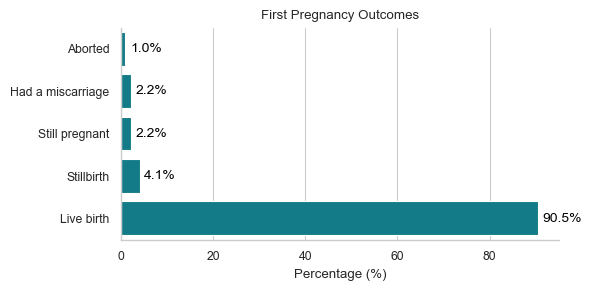

In [99]:
# How did the first pregnancy end?
preg_end_labels = {
    1: "Had a miscarriage",
    2: "Aborted",
    3: "Live birth",
    4: "Stillbirth",
    5: "Still pregnant"
}

# Count occurrences of each pregnancy outcome
preg_outcomes = df_insensitive['preg_end'].value_counts()

# Convert to percentages
preg_outcomes_percent = (preg_outcomes / preg_outcomes.sum()) * 100

# Convert index to category labels
preg_outcomes_percent.index = preg_outcomes_percent.index.map(preg_end_labels)

# Sort values for better readability
preg_outcomes_percent = preg_outcomes_percent.sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(6, 3))
ax = sns.barplot(x=preg_outcomes_percent.values, y=preg_outcomes_percent.index, color="#008b9a")

# Add percentage labels inside bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",  # Format percentage
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),  # Adjust position
                ha='left', va='center', fontsize=10, color='black')

# Labels and title
plt.xlabel("Percentage (%)")
plt.ylabel("")
plt.title("First Pregnancy Outcomes")
sns.despine(top=True, right=True)

# Show plot
plt.tight_layout()
plt.savefig(figures_path_effects + 'first_pregnancy_outcomes.png')
plt.show()

### Visit antenatal clinic

In [48]:
# Did you have any antenatal visit or care during the pregnancy for the last birth?
df_insensitive['preg_anten'].value_counts(normalize=True)

preg_anten
1.00   0.96
2.00   0.04
Name: proportion, dtype: float64

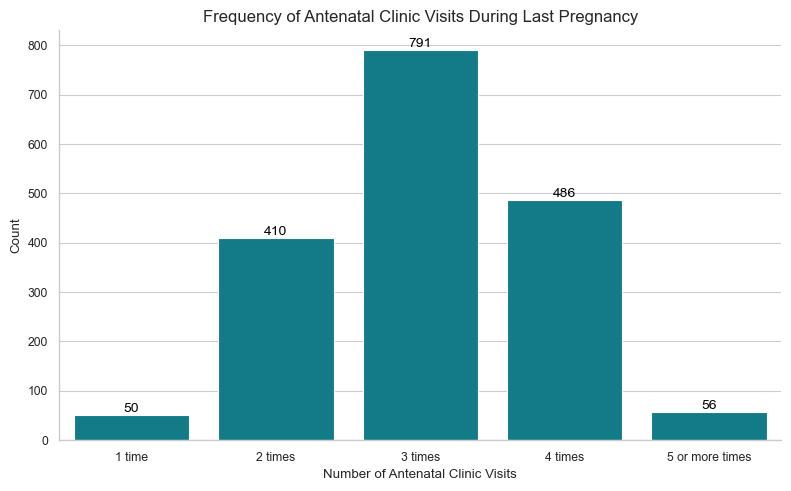

In [51]:
# How many times did you visit the antenatal clinic during your last pregnancy?
visit_clinic_labels = {
    0: "None",
    1: "1 time",
    2: "2 times",
    3: "3 times",
    4: "4 times",
    5: "5 or more times"
}

# Count occurrences of each response
visit_counts = df_insensitive['visit_clinic'].value_counts().sort_index()

# Convert index to category labels
visit_counts.index = visit_counts.index.map(visit_clinic_labels)

# Plot bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=visit_counts.index, y=visit_counts.values, color="#008b9a")

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",  # Display integer count
                (p.get_x() + p.get_width() / 2, p.get_height()),  # Position on top of bar
                ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Number of Antenatal Clinic Visits")
plt.ylabel("Count")
plt.title("Frequency of Antenatal Clinic Visits During Last Pregnancy", fontsize=12)
sns.despine(top=True, right=True)
plt.xticks(rotation=0)

# Show plot
plt.tight_layout()
plt.savefig(figures_path_effects + 'antenatal_clinic_visits.png', dpi=300)
plt.show()

In [52]:
# If you did not attend any antenatal clinic, what were the reasons for this?
didnt_attend_labels = {
    1: "Partner did not give me money for transport",
    2: "I never had money for transport",
    3: "Didn’t know that I was pregnant",
    4: "Did not know where to go for antenatal care",
    5: "I didn’t know that I needed to go for antenatal care",
    6: "I feared to go for antenatal care",
    7: "Other (specify)"
}

# Count occurrences of each reason
didnt_attend_counts = df_insensitive['didnt_attend'].value_counts()

# Get the highest and second-highest reasons
top_reasons = didnt_attend_counts.nlargest(2)

# Get labels and counts
reason_1, count_1 = didnt_attend_labels[top_reasons.index[0]], top_reasons.iloc[0]
reason_2, count_2 = didnt_attend_labels[top_reasons.index[1]], top_reasons.iloc[1]

# Print the automated summary
print(f"The most common reason for not attending any antenatal clinic was '{reason_1}' (n = {count_1}), followed by '{reason_2}' (n = {count_2}).")

The most common reason for not attending any antenatal clinic was 'Partner did not give me money for transport' (n = 72), followed by 'I never had money for transport' (n = 24).


### Last delivery

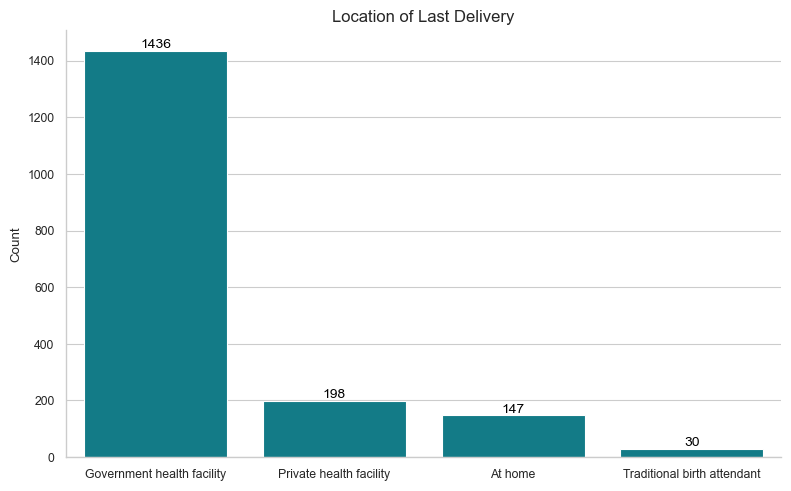

In [54]:
# Where did you have your last delivery?
labels = {
    1: "Government health facility",
    2: "Private health facility",
    3: "At home",
    4: "Traditional birth attendant",
}

# Count occurrences of each response
counts = df_insensitive['last_deliv'].value_counts().sort_index()

# Convert index to category labels
counts.index = counts.index.map(labels)

# Plot bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, color="#008b9a")

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",  # Display integer count
                (p.get_x() + p.get_width() / 2, p.get_height()),  # Position on top of bar
                ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("")
plt.ylabel("Count")
plt.title("Location of Last Delivery", fontsize=12)
sns.despine(top=True, right=True)
plt.xticks(rotation=0)

# Show plot
plt.tight_layout()
plt.savefig(figures_path_effects + 'place_last_delivery.png', dpi=300)
plt.show()

### Abortion practices

In [60]:
# Did you have any antenatal visit or care during the pregnancy for the last birth?
contingency_table = pd.crosstab(df_insensitive['attend_scol'], df_insensitive['had_abort'])
contingency_table = contingency_table.rename(columns={1.00: "Yes", 2.00: "No"})

table_pct = contingency_table.div(table.sum(axis=1), axis=0) * 100
table_pct = table_pct.round(0)
print("Proportion Table:")
print(table_pct)

print("\nCount Table:")
print(contingency_table)

# Run the chi-square test to obtain expected frequencies
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("\nChi-Square Test Results:")
print(f"Chi-square test statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

# Convert expected frequencies to a DataFrame for easier handling
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)

# Calculate standardized residuals: (observed - expected) / sqrt(expected)
observed = contingency_table.values
std_residuals = (observed - expected) / np.sqrt(expected)

# Create a DataFrame of the standardized residuals for clear presentation
std_residuals_df = pd.DataFrame(std_residuals, index=contingency_table.index, columns=contingency_table.columns)
print("\nStandardized Residuals:")
print(std_residuals_df)

Proportion Table:
had_abort  Yes    No
region              
Central   8.00 92.00
Eastern   4.00 96.00
Northern  9.00 91.00
Western   4.00 97.00

Count Table:
had_abort  Yes   No
region             
Central     32  352
Eastern     33  812
Northern    34  355
Western      9  235

Chi-Square Test Results:
Chi-square test statistic: 18.21
p-value: 0.0004
Degrees of freedom: 3

Standardized Residuals:
had_abort   Yes    No
region               
Central    2.06 -0.51
Eastern   -2.29  0.57
Northern   2.41 -0.60
Western   -1.37  0.34


## Other exploratory topics

### Willingness and prevention

In [65]:
# Create a contingency table from your DataFrame (assume it's named df_insensitive)
df_check = df_insensitive[df_insensitive['do_anything'] != 3.00]
contingency_table = pd.crosstab(df_check['will_sex_binary'], df_check['do_anything'])
print("Contingency Table:")
print(contingency_table)

# Run the chi-square test to obtain expected frequencies
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("\nChi-Square Test Results:")
print(f"Chi-square test statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

# Convert expected frequencies to a DataFrame for easier handling
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print("\nExpected Frequencies:")
print(expected_df)

# Calculate standardized residuals: (observed - expected) / sqrt(expected)
observed = contingency_table.values
std_residuals = (observed - expected) / np.sqrt(expected)

# Create a DataFrame of the standardized residuals for clear presentation
std_residuals_df = pd.DataFrame(std_residuals, index=contingency_table.index, columns=contingency_table.columns)
print("\nStandardized Residuals:")
print(std_residuals_df)

Contingency Table:
do_anything      1.00  2.00
will_sex_binary            
0.00              120   272
1.00              541   869

Chi-Square Test Results:
Chi-square test statistic: 7.61
p-value: 0.0058
Degrees of freedom: 1

Expected Frequencies:
do_anything       1.00   2.00
will_sex_binary              
0.00            143.79 248.21
1.00            517.21 892.79

Standardized Residuals:
do_anything      1.00  2.00
will_sex_binary            
0.00            -1.98  1.51
1.00             1.05 -0.80


In [66]:
# The first time you had sex, what did you use to avoid a pregnancy?
count = df_insensitive.loc[(df_insensitive['do_anything'] == 1.00)]

contraception = ['male_condom', 'female_condom', 'iud_coil', 'pill', 'withdrawal', 'implant', 'injection', 'emergency']

# Calculate count of '1's for each contraception
count_contraception = count[contraception].apply(lambda col: (col == 1).sum()).to_frame(name='Count')

# Calculate the total number of unique individuals who reported at least one contraception
total_individuals = (count[contraception] == 1).any(axis=1).sum()

# Correct proportions by dividing by unique individuals
count_contraception['Proportion'] = ((count_contraception['Count'] / total_individuals) * 100).round(0)

count_contraception = count_contraception.sort_values(by='Proportion', ascending=False)

# Extract the first row details
first_row_id = count_contraception.index[0]
first_row_count = count_contraception.iloc[0]['Count']
first_row_percentage = count_contraception.iloc[0]['Proportion']

# Display extracted values
print(f"The most reported pregnancy prevention methods were {first_row_id} used by {first_row_percentage}% ({first_row_count}).")

The most reported pregnancy prevention methods were male_condom used by 92.0% (584.0).


In [67]:
df_insensitive['will_sex'].value_counts()

will_sex
1.00    1441
3.00     252
2.00     200
4.00       6
Name: count, dtype: int64

The statistical test shows that there is a significant relationship (p-value = 0.0058) between a girl's willingness to have sex and whether she takes any action to prevent pregnancy. This means that whether someone is willing to have sex is linked to their likelihood of doing something to prevent pregnancy, rather than being purely random.

## Export